In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
base_path = Path.cwd().parent
snapshot_date = '2026-02-28'

In [3]:
df = pd.read_parquet(f"{str(base_path)}/data/silver/snapshot_date={snapshot_date}")

In [5]:
print(df.shape)
df = df.drop(columns=['_source_file', '_ingested_at'])
df.head()

(105208, 30)


,player_id,player,org,rounds_played,rating,average_combat_score,kill_deaths,kill_assists_survived_traded,average_damage_per_round,kills_per_round,...,first_kills,first_deaths,clutches_won,clutches_played,clutch_success_rate,_pipeline_version,event_id,region,map,agent
0,1016,4qu1la,HX,19,NaN,229.0,0.94,NaN,NaN,0.79,...,0,0,NaN,NaN,NaN,1.0.0,1,ap,ascent,breach
1,1744,Notoriouszx,BME,58,NaN,195.3,0.86,NaN,113.4,0.64,...,6,7,1.0,5.0,0.2,1.0.0,1,ap,ascent,breach
2,2388,THEELOVEFAMILY,FS,24,NaN,135.0,0.76,NaN,87.8,0.54,...,1,0,0.0,4.0,0.0,1.0.0,1,ap,ascent,breach
3,3345,Niino,AG,17,NaN,119.0,0.47,NaN,69.6,0.41,...,2,1,0.0,4.0,0.0,1.0.0,1,ap,ascent,breach
4,2389,newgen,SP,17,NaN,158.0,0.71,NaN,103.5,0.59,...,1,4,0.0,3.0,0.0,1.0.0,1,ap,ascent,breach


In [12]:
# Minimum rounds filter to exclude noise (e.g. stand-ins, 1-map players)
MIN_ROUNDS = 200

top_players = (
    df[df["rounds_played"] >= MIN_ROUNDS]
    .groupby(["player_id", "player", "org"])
    .agg(
        total_rounds=("rounds_played", "max"),
        avg_rating=("rating", "mean"),
        avg_acs=("average_combat_score", "mean"),
        avg_kd=("kill_deaths", "mean"),
        avg_kast=("kill_assists_survived_traded", "mean"),
        avg_hs_pct=("headshot_percentage", "mean"),
        avg_adr=("average_damage_per_round", "mean"),
    )
    .reset_index()
    .sort_values("avg_rating", ascending=False)
)

top_players.head(20)

,player_id,player,org,total_rounds,avg_rating,avg_acs,avg_kd,avg_kast,avg_hs_pct,avg_adr
571,8176,enerii,FLCV,299,1.520000,334.250000,1.815000,0.810000,0.275000,207.000000
408,4386,LeviathanAG,NBG,224,1.490000,277.700000,1.740000,0.850000,0.160000,165.900000
570,8175,Ayumiii,HYPA,202,1.480000,300.900000,1.960000,0.800000,0.240000,186.700000
649,10338,Lime,EP,204,1.380000,281.700000,1.410000,0.770000,0.220000,189.400000
237,1885,purp0,TL,234,1.380000,281.600000,1.560000,0.770000,0.380000,179.500000
684,11901,caydia,MAK,206,1.370000,257.700000,1.600000,0.790000,0.230000,162.900000
934,28198,Snackie,246,246,1.370000,277.700000,1.430000,0.780000,0.270000,171.000000
305,2764,DaveeyS,KRÜ,218,1.360000,245.300000,1.610000,0.780000,0.280000,161.000000
817,17323,mimi,G2G,219,1.360000,245.050000,1.615000,0.815000,0.250000,166.050000
746,14312,Padge,NIP.LI,309,1.353333,283.933333,1.536667,0.776667,0.306667,177.333333


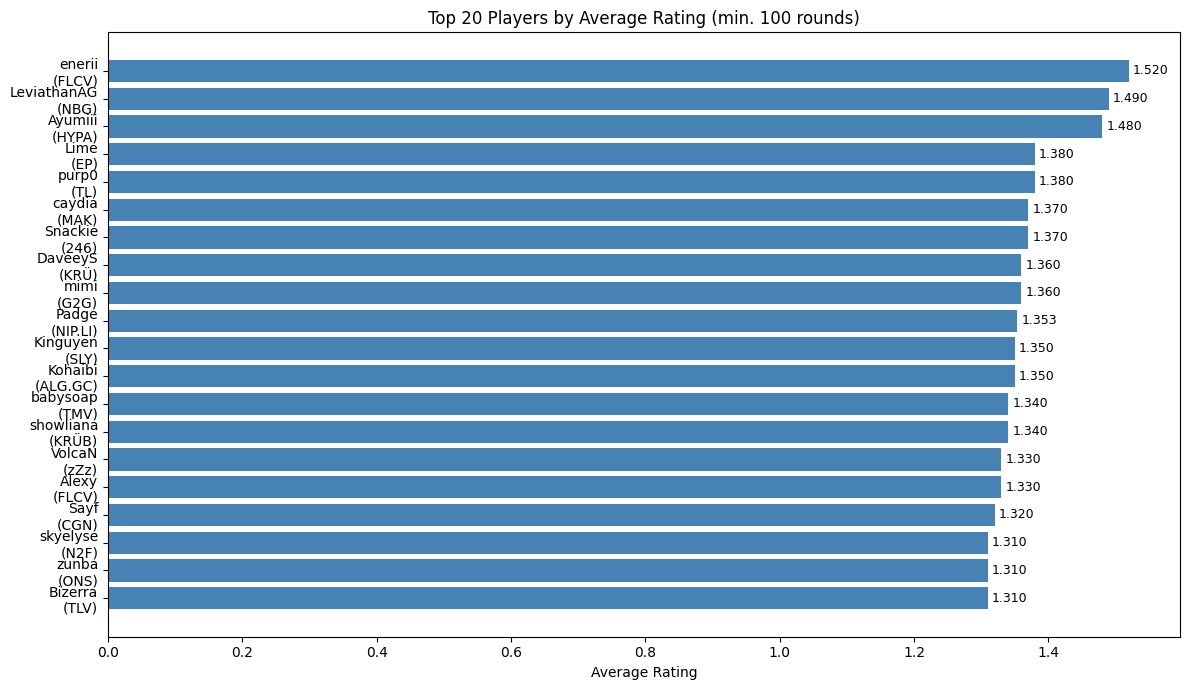

In [ ]:
top20 = top_players.head(20).copy()
top20["label"] = top20["player"] + "\n(" + top20["org"] + ")"

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20["label"][::-1], top20["avg_rating"][::-1], color="steelblue")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlabel("Average Rating")
ax.set_title("Top 20 Players by Average Rating (min. 100 rounds)")
plt.tight_layout()
plt.show()

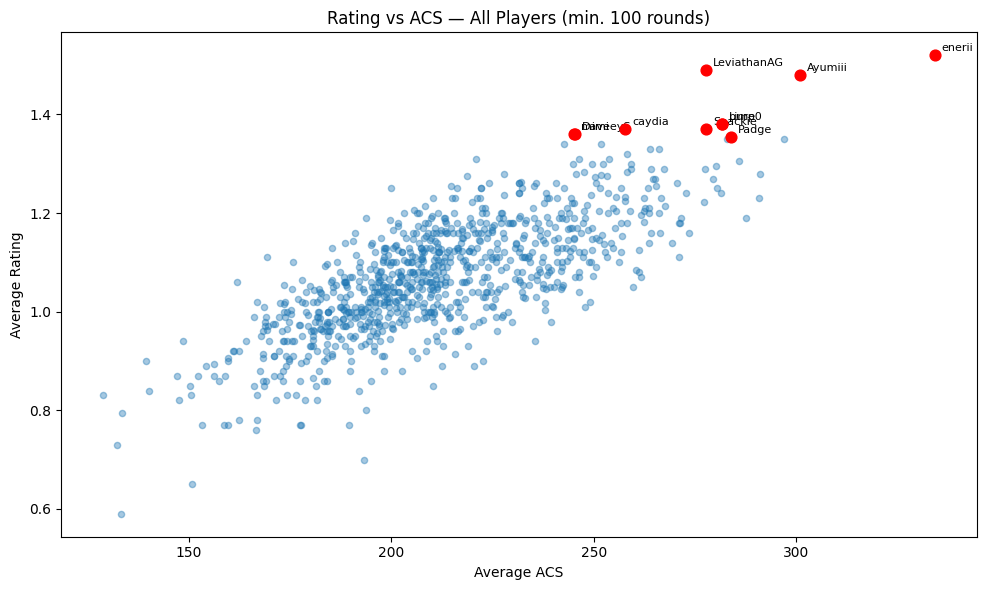

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(top_players["avg_acs"], top_players["avg_rating"], alpha=0.4, s=20)

# Highlight top 10
top10 = top_players.head(10)
ax.scatter(top10["avg_acs"], top10["avg_rating"], color="red", s=60, zorder=5)
for _, row in top10.iterrows():
    ax.annotate(row["player"], (row["avg_acs"], row["avg_rating"]), fontsize=8, xytext=(5, 3), textcoords="offset points")

ax.set_xlabel("Average ACS")
ax.set_ylabel("Average Rating")
ax.set_title("Rating vs ACS — All Players (min. 100 rounds)")
plt.tight_layout()
plt.show()

In [13]:
df['rating'].unique()

array([ nan, 1.25, 1.02, 1.21, 0.86, 0.66, 0.67, 1.31, 0.97, 0.92, 0.89,
       0.71, 0.84, 1.19, 0.81, 0.58, 0.88, 0.87, 1.3 , 0.91, 1.06, 0.9 ,
       1.07, 0.98, 0.96, 1.14, 1.09, 1.16, 1.  , 1.08, 0.61, 1.17, 0.65,
       1.1 , 0.7 , 0.6 , 0.37, 0.52, 1.13, 0.83, 0.36, 0.95, 0.63, 0.56,
       0.99, 1.42, 0.94, 1.01, 0.62, 1.23, 1.15, 0.82, 1.03, 0.32, 1.05,
       1.43, 0.72, 1.12, 1.04, 1.26, 1.18, 0.79, 0.59, 0.75, 0.42, 1.11,
       0.73, 0.39, 1.37, 0.77, 1.32, 0.55, 0.76, 0.35, 0.33, 0.22, 0.64,
       0.69, 0.53, 0.3 , 0.26, 0.06, 0.44, 0.8 , 0.5 , 0.29, 0.85, 0.78,
       1.49, 0.05, 0.04, 0.48, 0.12, 0.41, 1.2 , 0.45, 1.27, 2.16, 1.22,
       0.68, 1.6 , 0.57, 0.46, 1.34, 0.24, 0.47, 0.43, 1.39, 0.4 , 1.62,
       1.52, 0.13, 0.54, 1.64, 0.93, 1.59, 1.24, 1.35, 0.49, 1.75, 0.28,
       0.51, 1.28, 1.58, 1.73, 0.16, 0.74, 0.38, 0.34, 0.21, 0.1 , 1.38,
       2.6 , 1.33, 1.68, 1.45, 1.97, 1.29, 0.07, 0.03, 1.65, 1.67, 0.25,
       1.54, 1.41, 0.23, 0.18, 1.5 , 1.57, 1.74, 1.